# Time Series Forecasting with Transformers 🕸️

In this notebook, we will use a **PyTorch Transformer** architecture for time series forecasting.
Transformers, originally designed for NLP tasks (like translating text), have proven incredibly powerful for time series data because of their **Self-Attention Mechanism**, which allows the model to look at the entire sequence and weigh the importance of different time steps simultaneously.

### Key Concepts:
1. **Positional Encoding:** Since Transformers don't process data sequentially (unlike RNNs/LSTMs), we must explicitly inject information about the relative or absolute position of the time steps.
2. **Self-Attention:** The model learns which past time steps are most relevant for predicting the future step, regardless of how far back they occurred.
3. **Encoder-Decoder vs Encoder-Only:** For simple time series forecasting, we often use an Encoder-only architecture with a linear head mapping the final embeddings to continuous predictions.

Let's dive in using the `airline_passengers` dataset!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import math

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Preprocessing

We'll use the classic Airline Passengers dataset. We need to normalize it since neural networks are highly sensitive to unscaled data.

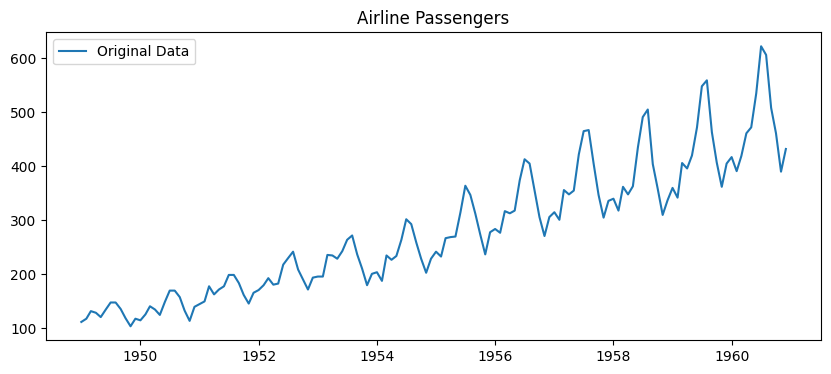

In [2]:
# Load the dataset
df = pd.read_csv('data/airline_passengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot
plt.figure(figsize=(10,4))
plt.plot(df.index, df['Thousands of Passengers'], label='Original Data')
plt.title('Airline Passengers')
plt.legend()
plt.show()

In [3]:
# Scale the data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(df['Thousands of Passengers'].values.reshape(-1,1))

## 2. Sequence Creation (Sliding Window)

Just like with LSTMs or CNNs, we must frame the time series as a supervised learning problem. We use a sliding window to create sequences of length `seq_length` to predict the next `1` value.

In [4]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 12 # Predict next month using the past 12 months (1 year)
X, y = create_sequences(scaled_data, seq_length)

# Train-Test Split (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Convert to PyTorch Tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: torch.Size([105, 12, 1])
y_train shape: torch.Size([105, 1])


## 3. Building the Transformer Model

The PyTorch Transformer expects input of shape `(Sequence Length, Batch Size, Features)` by default unless `batch_first=True` is specified.

We will build two components:
1.  **Positional Encoding Module:** Adds sine and cosine waves of different frequencies to the input embeddings so the model understands the order of the sequence.
2.  **Transformer Regressor:** The main neural network containing the PyTorch `TransformerEncoder`.

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        x = x + self.pe[:x.size(0), :]
        return x

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()
        self.model_type = 'Transformer'
        
        # Linear layer to map the 1D input into d_model dimensions
        self.input_linear = nn.Linear(input_size, d_model)
        
        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        # Final linear layer to map back to 1D output
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        # src shape expected: (batch_size, seq_len, features)
        # We need to swap to (seq_len, batch_size, features) for PyTorch's default Transformer
        src = src.permute(1, 0, 2)
        
        # Map input to d_model space
        src = self.input_linear(src)
        
        # Add positional encoding
        src = self.pos_encoder(src)
        
        # Pass through Transformer
        output = self.transformer_encoder(src)
        
        # We only care about the output of the last time step for forecasting
        # output shape is (seq_len, batch_size, d_model) -> take index -1
        output = output[-1, :, :]
        
        # Pass through linear decoder
        output = self.decoder(output)
        return output

## 4. Model Initialization and Training

In [6]:
# Hyperparameters
EPOCHS = 150
BATCH_SIZE = 16
LR = 0.001

# Create DataLoaders
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

# Initialize Model, Loss, and Optimizer
model = TimeSeriesTransformer(input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

TimeSeriesTransformer(
  (input_linear): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=64, out_features=1, bias=True)
)


In [7]:
# Training Loop
losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_x)
        
        # Calculate loss
        loss = criterion(predictions, batch_y)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
        
    avg_loss = np.mean(batch_losses)
    losses.append(avg_loss)
    
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}')

Epoch [25/150], Loss: 0.007350
Epoch [50/150], Loss: 0.005482
Epoch [75/150], Loss: 0.005411
Epoch [100/150], Loss: 0.004477
Epoch [125/150], Loss: 0.003668
Epoch [150/150], Loss: 0.002540


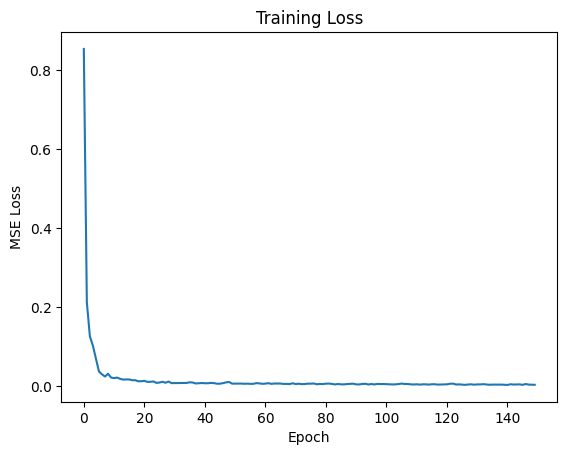

In [8]:
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

## 5. Evaluation and Forecasting

Let's evaluate the model on the test set and plot the actual vs predicted values.

In [9]:
# Evaluation
model.eval()
test_predictions = []

with torch.no_grad():
    for i in range(len(X_test)):
        # Shape: (1, seq_length, 1)
        x_input = X_test[i].unsqueeze(0)
        y_pred = model(x_input)
        test_predictions.append(y_pred.item())

# Inverse transform the predictions and actual values to original scale
test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

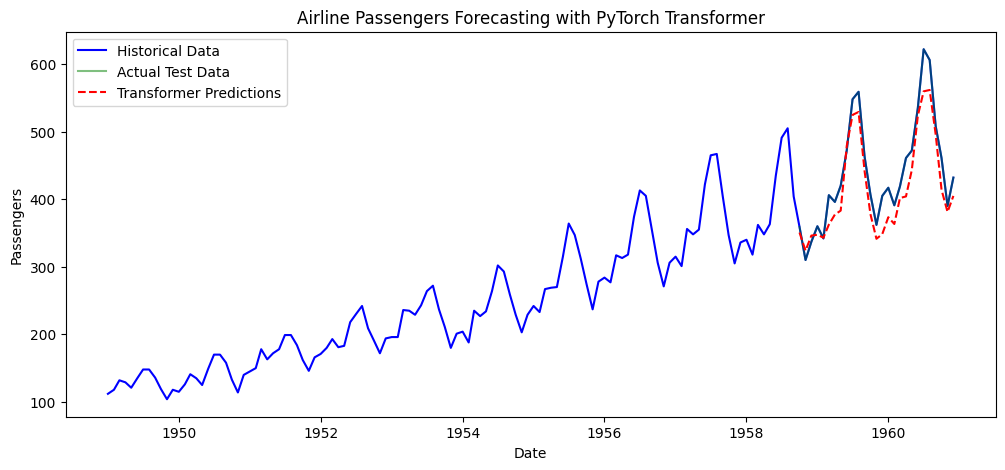

In [10]:
# Create a DataFrame for plotting
train_size_full = len(X_train) + seq_length
test_index = df.index[train_size_full:]

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Thousands of Passengers'], label='Historical Data', color='blue')
plt.plot(test_index, y_test_actual, label='Actual Test Data', color='green', alpha=0.5)
plt.plot(test_index, test_predictions, label='Transformer Predictions', color='red', linestyle='--')
plt.title('Airline Passengers Forecasting with PyTorch Transformer')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()